# Week-3 Exploratory Data Analysis of Enriched Bike Rental Demand Data
## 1. Introduction

This notebook explores the enriched bike rental dataset produced by the Dagster pipeline.

In the updated pipeline, **artificially generated zero-demand rows** are no longer included. Therefore, this analysis directly focuses on recorded rental demand observations.

The target variable is total_count, representing the total number of recorded bike rentals for one hourly-location observation.

This notebook investigates:

- the structure and quality of the processed dataset;
- the distribution of recorded rental demand;
- the composition of registered and direct rentals;
- demand patterns across time, location, weather, and holiday conditions;
- useful candidate features for later regression modeling.

## 2. Data Overview
### 2.1 Load Dataset and Inspect Structure

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

analysis_data = pd.read_csv(
    "../data/processed/final_enriched_rental_data.csv",
    parse_dates=["hour", "date"]
)

,hour,location_id,direct_count,registered_count,total_count,date,hour_of_day,day_of_week,month,is_weekend,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,holiday,is_holiday,is_workday
0,2011-01-01,2,1,0,1,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0
1,2011-01-01,3,0,1,1,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0
2,2011-01-01,4,0,2,2,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0
3,2011-01-01,5,1,0,1,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0
4,2011-01-01,9,0,1,1,2011-01-01,0,5,1,1,clear,3.3,3.0,81.0,0.0,Not a holiday,0,0


In [3]:
# overview helper
def show_results(**results):
    """Display multiple labelled notebook results in one cell."""
    
    for label, result in results.items():
        print(f"\n{label}:")
        display(result)

In [16]:
show_results(
    shape=analysis_data.shape,
    columns=analysis_data.columns.tolist(),
    first_rows=analysis_data.head(),
)

analysis_data.info()


shape:


(312386, 21)


columns:


['hour',
 'location_id',
 'direct_count',
 'registered_count',
 'total_count',
 'date',
 'hour_of_day',
 'day_of_week',
 'month',
 'is_weekend',
 'conditions',
 'temperature_c',
 'perceived_temperature_c',
 'humidity',
 'windspeed_kmh',
 'holiday',
 'is_holiday',
 'is_workday',
 'day_name',
 'month_name',
 'quarter']


first_rows:


,hour,location_id,direct_count,registered_count,total_count,date,hour_of_day,day_of_week,month,is_weekend,...,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,holiday,is_holiday,is_workday,day_name,month_name,quarter
0,2011-01-01,2,1,0,1,2011-01-01,0,5,1,1,...,3.3,3.0,81.0,0.0,Not a holiday,0,0,Saturday,Jan,1
1,2011-01-01,3,0,1,1,2011-01-01,0,5,1,1,...,3.3,3.0,81.0,0.0,Not a holiday,0,0,Saturday,Jan,1
2,2011-01-01,4,0,2,2,2011-01-01,0,5,1,1,...,3.3,3.0,81.0,0.0,Not a holiday,0,0,Saturday,Jan,1
3,2011-01-01,5,1,0,1,2011-01-01,0,5,1,1,...,3.3,3.0,81.0,0.0,Not a holiday,0,0,Saturday,Jan,1
4,2011-01-01,9,0,1,1,2011-01-01,0,5,1,1,...,3.3,3.0,81.0,0.0,Not a holiday,0,0,Saturday,Jan,1


<class 'pandas.DataFrame'>
RangeIndex: 312386 entries, 0 to 312385
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   hour                     312386 non-null  datetime64[us]
 1   location_id              312386 non-null  int64         
 2   direct_count             312386 non-null  int64         
 3   registered_count         312386 non-null  int64         
 4   total_count              312386 non-null  int64         
 5   date                     312386 non-null  datetime64[us]
 6   hour_of_day              312386 non-null  int64         
 7   day_of_week              312386 non-null  int64         
 8   month                    312386 non-null  int64         
 9   is_weekend               312386 non-null  int64         
 10  conditions               312386 non-null  str           
 11  temperature_c            312386 non-null  float64       
 12  perceived_temperature_c  31

### 2.2 Data Quality Checks

In [5]:
quality_checks = pd.Series({
    "missing_values": analysis_data.isna().sum().sum(),
    "zero_total_demand_rows": (analysis_data["total_count"] == 0).sum(),
    "total_count_is_consistent": (
        analysis_data["total_count"]
        == analysis_data["registered_count"] + analysis_data["direct_count"]
    ).all()
})

show_results(
    summary_statistics=analysis_data.describe(include="all").T,
    quality_checks=quality_checks
)


summary_statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
hour,312386,NaN,NaN,NaN,2012-01-09 06:47:13.525190,2011-01-01 00:00:00,2011-07-13 13:00:00,2012-01-12 08:00:00,2012-07-08 08:45:00,2012-12-31 23:00:00,NaN
location_id,312386.0,NaN,NaN,NaN,10.000592,0.0,5.0,10.0,15.0,20.0,6.055018
direct_count,312386.0,NaN,NaN,NaN,1.984778,0.0,0.0,1.0,3.0,28.0,2.785489
registered_count,312386.0,NaN,NaN,NaN,8.555639,0.0,3.0,7.0,12.0,59.0,7.637422
total_count,312386.0,NaN,NaN,NaN,10.540418,1.0,3.0,8.0,15.0,64.0,9.01275
date,312386,NaN,NaN,NaN,2012-01-08 18:02:46.916571,2011-01-01 00:00:00,2011-07-13 00:00:00,2012-01-12 00:00:00,2012-07-08 00:00:00,2012-12-31 00:00:00,NaN
hour_of_day,312386.0,NaN,NaN,NaN,12.740725,0.0,8.0,13.0,18.0,23.0,6.505371
day_of_week,312386.0,NaN,NaN,NaN,3.03883,0.0,1.0,3.0,5.0,6.0,2.001738
month,312386.0,NaN,NaN,NaN,6.608494,1.0,4.0,7.0,10.0,12.0,3.380686
is_weekend,312386.0,NaN,NaN,NaN,0.293387,0.0,0.0,0.0,1.0,1.0,0.455315



quality_checks:


missing_values                  0
zero_total_demand_rows          0
total_count_is_consistent    True
dtype: object

### 2.3 Target Distribution
Target: total_count <br>
Rental composition: registered_count, direct_count<br>
Time-related features: hour_of_day, day_of_week, month, quarter, is_weekend, is_workday, is_holiday<br>
Location-related feature: location_id<br>
Weather-related features: conditions, temperature_c, perceived_temperature_c, humidity, windspeed_kmh<br>

In [13]:
target_summary = analysis_data["total_count"].describe()
target_skewness = analysis_data["total_count"].skew()
maximum_demand = int(analysis_data["total_count"].max())

show_results(
    target_summary=target_summary,
    target_skewness=target_skewness,
    maximum_demand=maximum_demand,
)


target_summary:


count    312386.000000
mean         10.540418
std           9.012750
min           1.000000
25%           3.000000
50%           8.000000
75%          15.000000
max          64.000000
Name: total_count, dtype: float64


target_skewness:


np.float64(1.3264952397680487)


maximum_demand:


64

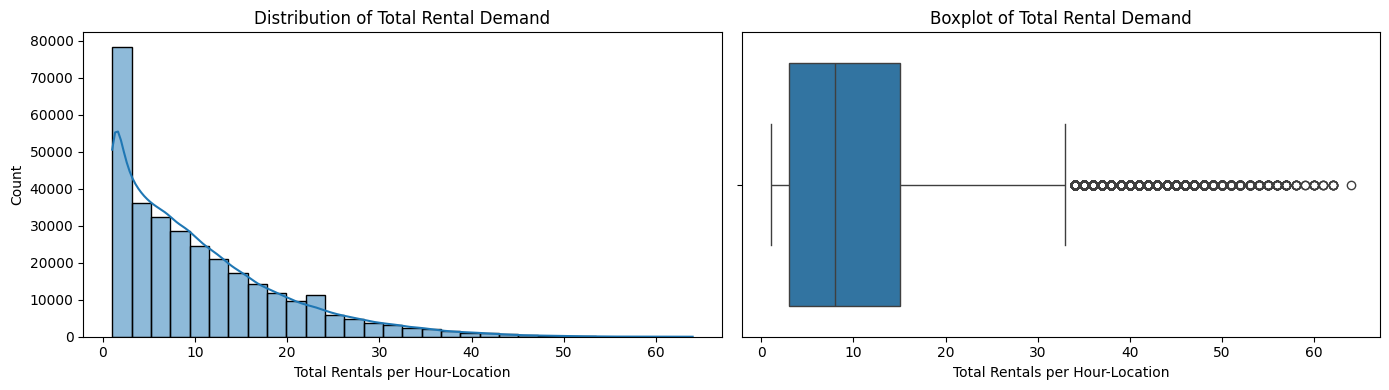

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(analysis_data["total_count"], bins=30, kde=True, ax=axes[0])
sns.boxplot(x=analysis_data["total_count"], ax=axes[1])

axes[0].set_title("Distribution of Total Rental Demand")
axes[0].set_xlabel("Total Rentals per Hour-Location")

axes[1].set_title("Boxplot of Total Rental Demand")
axes[1].set_xlabel("Total Rentals per Hour-Location")

plt.tight_layout()
plt.show()

The distribution of `total_count` is right-skewed, with many hourly-location observations showing relatively low rental demand and a smaller number of observations showing much higher demand. This suggests that rental demand varies considerably across time and location.

## 3. Reantal Type Composition

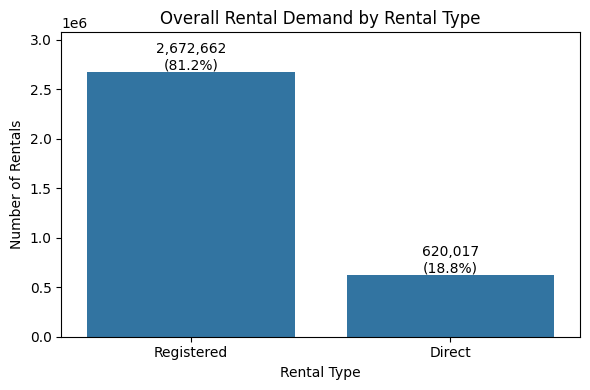


rental_composition:


,rental_type,rental_count,percentage
0,Registered,2672662,81.169832
1,Direct,620017,18.830168


In [7]:
composition = (
    analysis_data[["registered_count", "direct_count"]]
    .sum()
    .rename({
        "registered_count": "Registered",
        "direct_count": "Direct"
    })
    .rename_axis("rental_type")
    .reset_index(name="rental_count")
)

composition["percentage"] = (
    composition["rental_count"] / composition["rental_count"].sum() * 100
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=composition,
    x="rental_type",
    y="rental_count"
)

for i, row in composition.iterrows():
    ax.text(
        i,
        row["rental_count"],
        f'{row["rental_count"]:,}\n({row["percentage"]:.1f}%)',
        ha="center",
        va="bottom"
    )

plt.ylim(0, composition["rental_count"].max() * 1.15)
plt.title("Overall Rental Demand by Rental Type")
plt.xlabel("Rental Type")
plt.ylabel("Number of Rentals")
plt.tight_layout()
plt.show()

show_results(rental_composition=composition)

This result suggests that the overall rental pattern is mainly driven by registered users.

## 4. Time Pattern Analysis
### 4.1 Hourly Demand Pattern

In [21]:
# preparation hourly demand data for later EDA
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

hourly_data = (
    analysis_data
    .groupby("hour", as_index=False)
    .agg(
        registered_count=("registered_count", "sum"),
        direct_count=("direct_count", "sum"),
        total_count=("total_count", "sum"),
        is_weekend=("is_weekend", "first"),
        is_holiday=("is_holiday", "first"),
        is_workday=("is_workday", "first")
    )
)
hourly_data["hour_of_day"] = hourly_data["hour"].dt.hour
hourly_data["day_of_week"] = hourly_data["hour"].dt.dayofweek

hourly_data["day_name"] = pd.Categorical(
    hourly_data["hour"].dt.day_name(),
    categories=day_order,
    ordered=True
)

hourly_data["month_name"] = pd.Categorical(
    hourly_data["hour"].dt.strftime("%b"),
    categories=month_order,
    ordered=True
)

hourly_data["quarter"] = hourly_data["hour"].dt.quarter

hourly_data["day_type"] = np.select(
    [
        hourly_data["is_holiday"].eq(1),
        hourly_data["is_weekend"].eq(1)
    ],
    ["Holiday", "Weekend"],
    default="Workday"
)

show_results(
    analysis_data_shape=analysis_data.shape,
    hourly_data_shape=hourly_data.shape,
    unique_hour_check=hourly_data["hour"].is_unique,
    # first_hourly_rows=hourly_data.head()
)


analysis_data_shape:


(312386, 21)


hourly_data_shape:


(17379, 13)


unique_hour_check:


True

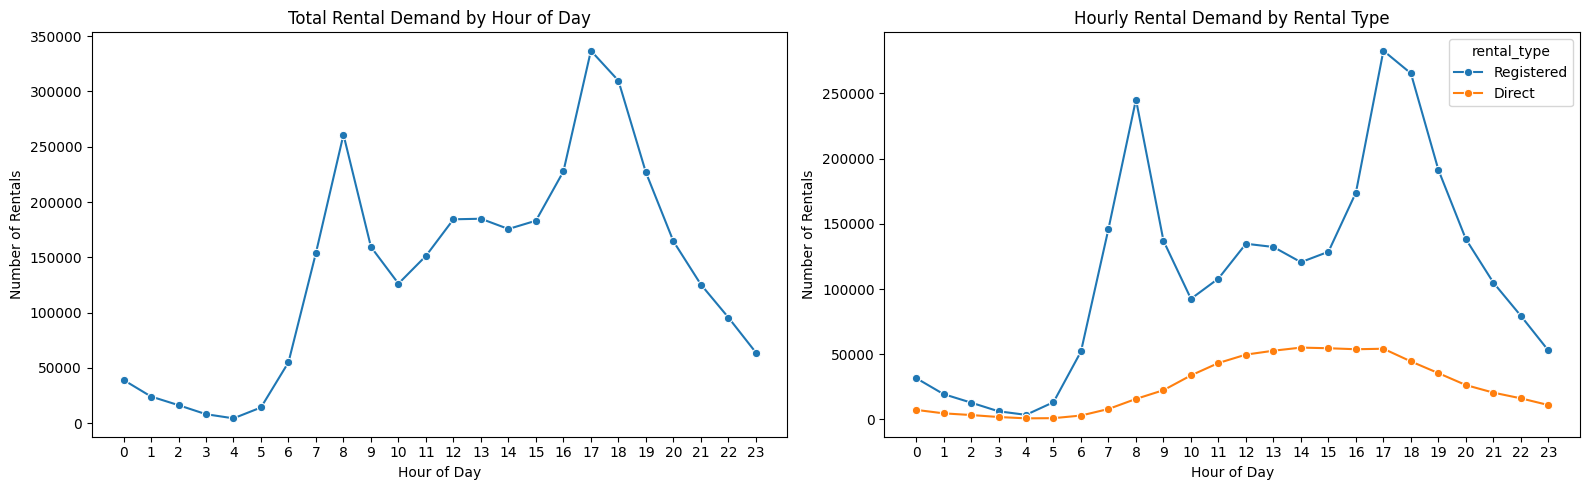

In [22]:
hourly_demand = (
    hourly_data
    .groupby("hour_of_day", as_index=False)[
        ["registered_count", "direct_count", "total_count"]
    ]
    .sum()
)

hourly_type_demand = hourly_demand.melt(
    id_vars="hour_of_day",
    value_vars=["registered_count", "direct_count"],
    var_name="rental_type",
    value_name="rental_count"
)

hourly_type_demand["rental_type"] = hourly_type_demand["rental_type"].map({
    "registered_count": "Registered",
    "direct_count": "Direct"
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left chart: overall hourly demand
sns.lineplot(
    data=hourly_demand,
    x="hour_of_day",
    y="total_count",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Total Rental Demand by Hour of Day")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Rentals")
axes[0].set_xticks(range(0, 24))

# Right chart: registered vs direct hourly demand
sns.lineplot(
    data=hourly_type_demand,
    x="hour_of_day",
    y="rental_count",
    hue="rental_type",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Hourly Rental Demand by Rental Type")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Number of Rentals")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

Total rental demand shows a clear daily time pattern with two peaks: a morning peak at around **08:00** and a larger evening peak at around **17:00–18:00**. Demand is lowest during the night and early morning hours, especially between **00:00 and 05:00**.

Registered rentals contributes mostly to the total demand curve. Direct rentals follow a different and smoother pattern, which gradually increases during the day and remains relatively high in the afternoon.

These observations suggest that `hour_of_day` is likely to be an important modeling feature. However.

### 4.2 Demand by day of week

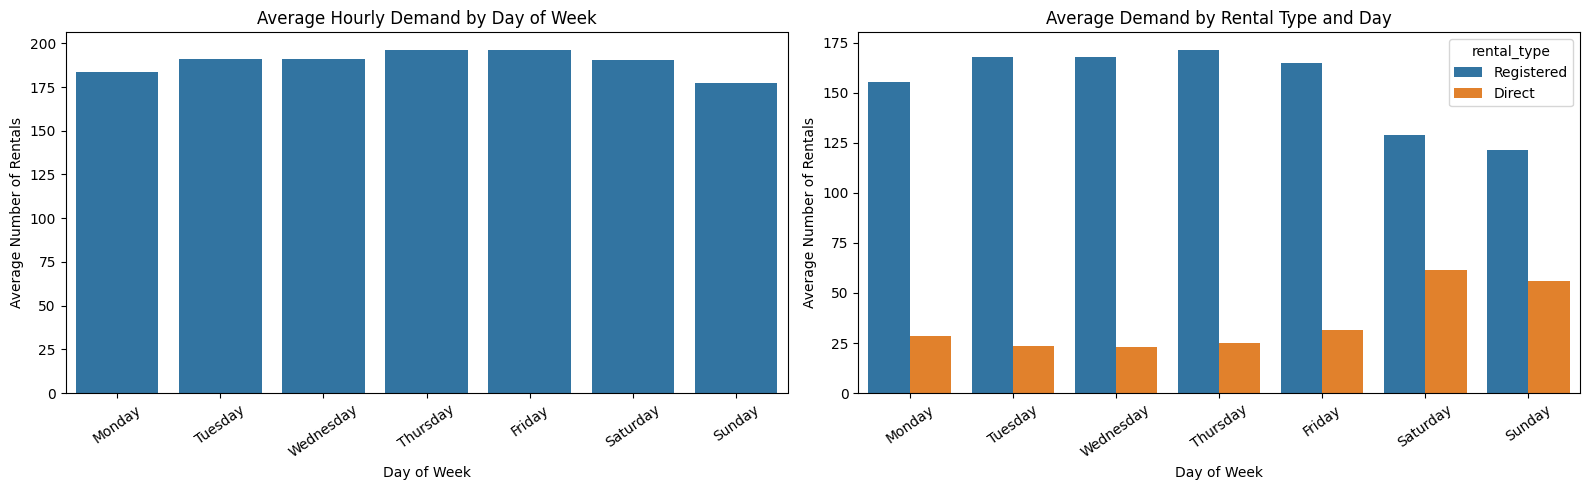


daily_average_demand:


,day_name,registered_count,direct_count,total_count
0,Monday,155.19,28.55,183.74
1,Tuesday,167.66,23.58,191.24
2,Wednesday,167.97,23.16,191.13
3,Thursday,171.56,24.87,196.44
4,Friday,164.68,31.46,196.14
5,Saturday,128.96,61.25,190.21
6,Sunday,121.31,56.16,177.47


In [23]:
daily_average_demand = (
    hourly_data
    .groupby("day_name", observed=True, as_index=False)[
        ["registered_count", "direct_count", "total_count"]
    ]
    .mean()
)

daily_type_demand = daily_average_demand.melt(
    id_vars="day_name",
    value_vars=["registered_count", "direct_count"],
    var_name="rental_type",
    value_name="average_demand"
)

daily_type_demand["rental_type"] = daily_type_demand["rental_type"].replace({
    "registered_count": "Registered",
    "direct_count": "Direct"
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=daily_average_demand,
    x="day_name",
    y="total_count",
    ax=axes[0]
)

sns.barplot(
    data=daily_type_demand,
    x="day_name",
    y="average_demand",
    hue="rental_type",
    ax=axes[1]
)

axes[0].set_title("Average Hourly Demand by Day of Week")
axes[1].set_title("Average Demand by Rental Type and Day")

for ax in axes:
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Average Number of Rentals")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

show_results(
    daily_average_demand=daily_average_demand.round(2)
)

Average hourly total demand is relatively stable throughout the week. However, the rental-type comparison reveals a clearer difference: registered demand is substantially lower on weekends, especially on Sunday, whereas direct demand increases strongly on Saturday and Sunday.

### 4.3 Workday, weekend, and holiday comparison 

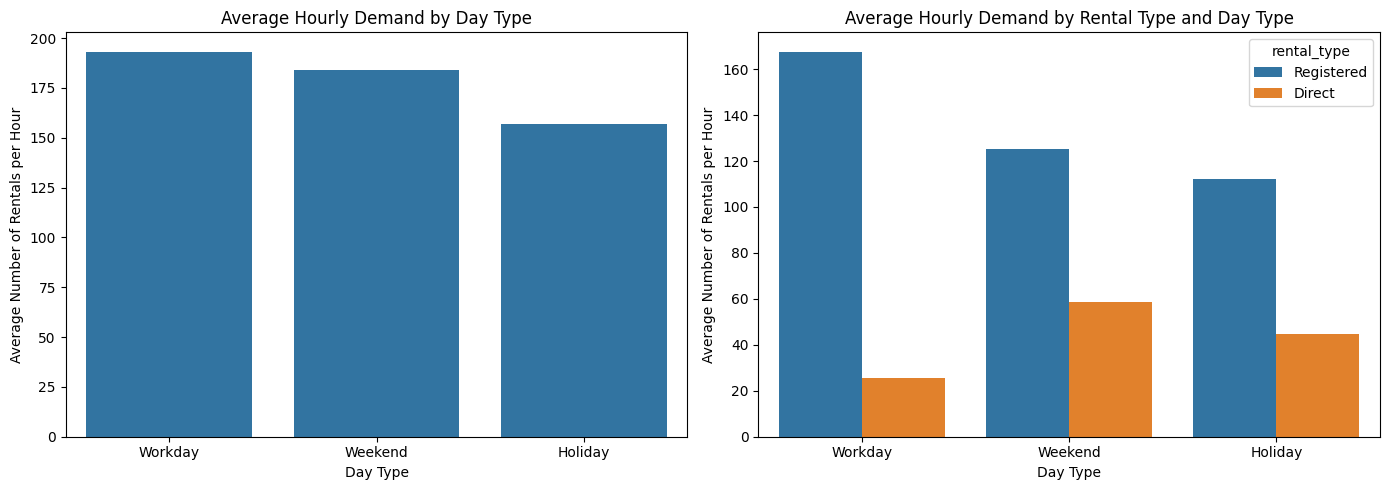

In [28]:
day_type_order = ["Workday", "Weekend", "Holiday"]

hourly_data["day_type"] = pd.Categorical(
    hourly_data["day_type"],
    categories=day_type_order,
    ordered=True
)

day_type_average = (
    hourly_data
    .groupby("day_type", observed=False, as_index=False)[
        ["registered_count", "direct_count", "total_count"]
    ]
    .mean()
)


day_type_long = day_type_average.melt(
    id_vars="day_type",
    value_vars=["registered_count", "direct_count"],
    var_name="rental_type",
    value_name="average_demand"
)

day_type_long["rental_type"] = day_type_long["rental_type"].replace({
    "registered_count": "Registered",
    "direct_count": "Direct"
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: average total demand by day type
sns.barplot(
    data=day_type_average,
    x="day_type",
    y="total_count",
    ax=axes[0]
)

axes[0].set_title("Average Hourly Demand by Day Type")
axes[0].set_xlabel("Day Type")
axes[0].set_ylabel("Average Number of Rentals per Hour")

# Right chart: registered vs direct by day type
sns.barplot(
    data=day_type_long,
    x="day_type",
    y="average_demand",
    hue="rental_type",
    ax=axes[1]
)

axes[1].set_title("Average Hourly Demand by Rental Type and Day Type")
axes[1].set_xlabel("Day Type")
axes[1].set_ylabel("Average Number of Rentals per Hour")

plt.tight_layout()
plt.show()

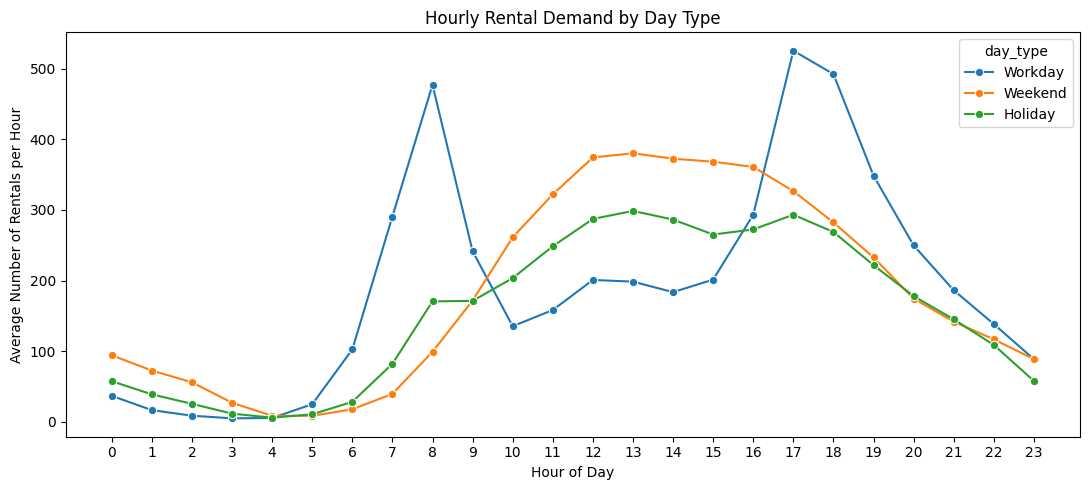

In [27]:
# hourly demand in differenct day types
day_type_hourly = (
    hourly_data
    .groupby(["day_type", "hour_of_day"], observed=True, as_index=False)["total_count"]
    .mean()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=day_type_hourly,
    x="hour_of_day",
    y="total_count",
    hue="day_type",
    marker="o"
)

plt.title("Hourly Rental Demand by Day Type")
plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Rentals per Hour")
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

Workdays have the highest average hourly total demand, while holidays show the lowest overall average demand. 

Weekend demand increases gradually during the morning and remains highest from around 12:00 to 16:00.

Holiday demand follows a pattern closer to weekends than workdays. However, holiday results should be interpreted cautiously because the number of observations is likely much smaller than the other two.

### 4.4 weekday-hour heatmap

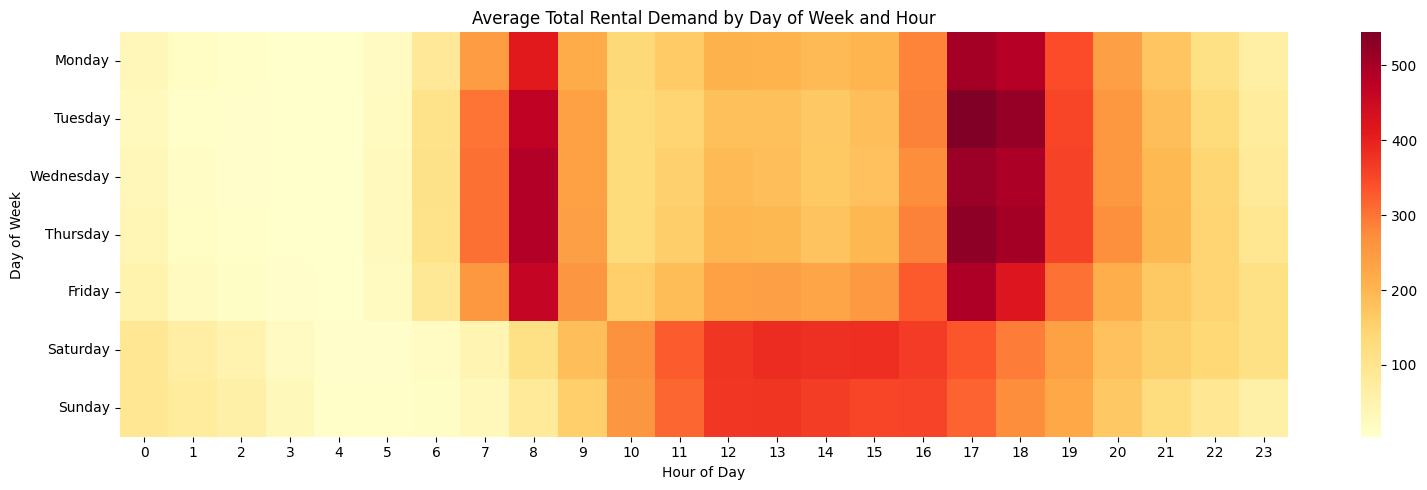


top_weekday_hour_combinations:


,day_name,hour_of_day,total_count
0,Tuesday,17,544.28
1,Thursday,17,527.35
2,Tuesday,18,517.57
3,Wednesday,17,513.14
4,Monday,17,502.39
5,Thursday,18,502.10
6,Wednesday,18,494.03
7,Friday,17,492.41
8,Thursday,8,488.57
9,Wednesday,8,488.33


In [32]:
weekday_hour_demand = (
    hourly_data
    .groupby(["day_name", "hour_of_day"], observed=True, as_index=False)["total_count"]
    .mean()
)

weekday_hour_pivot = weekday_hour_demand.pivot(
    index="day_name",
    columns="hour_of_day",
    values="total_count"
)

plt.figure(figsize=(16, 5))

sns.heatmap(
    weekday_hour_pivot,
    cmap="YlOrRd",
    annot=False
)

plt.title("Average Total Rental Demand by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

top_weekday_hours = (
    weekday_hour_demand
    .sort_values("total_count", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

show_results(
    top_weekday_hour_combinations=top_weekday_hours.round(2)
)

Top demand combination: Tuesday 17:00

### 4.5 Demand by month / quarter

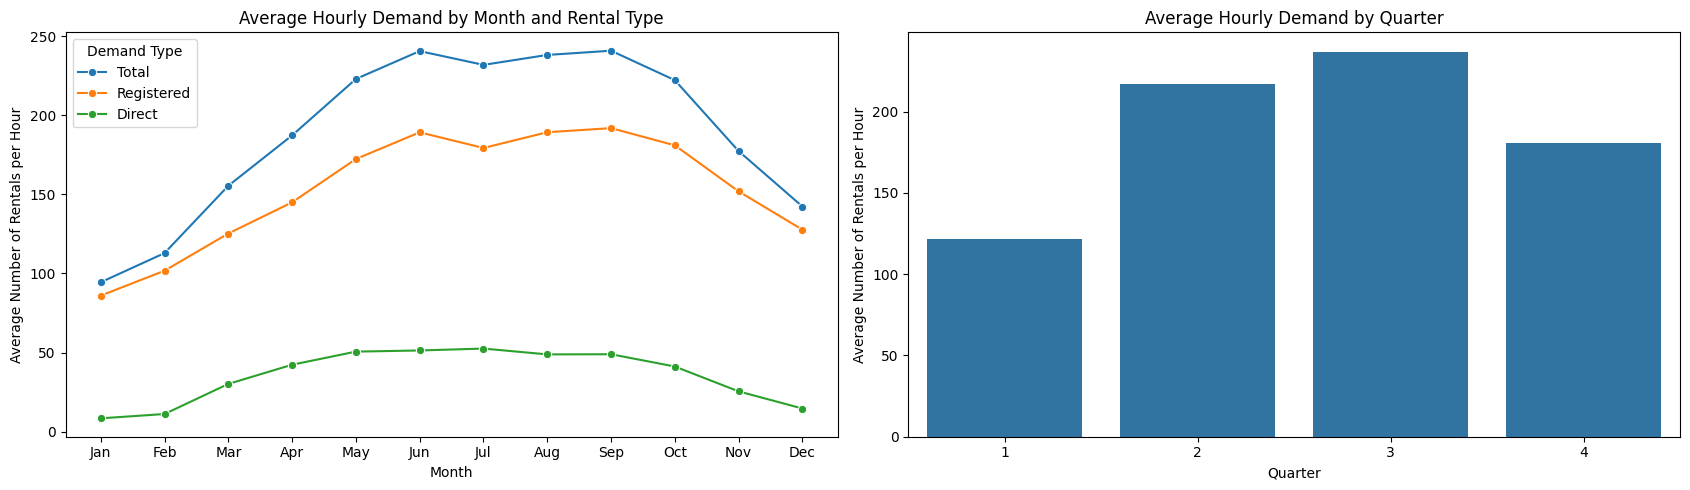


monthly_average_demand:


,month_name,registered_count,direct_count,total_count
0,Jan,86.00,8.43,94.42
1,Feb,101.71,11.16,112.87
2,Mar,125.24,30.17,155.41
3,Apr,144.95,42.31,187.26
4,May,172.31,50.59,222.91
5,Jun,189.19,51.32,240.52
6,Jul,179.30,52.52,231.82
7,Aug,189.26,48.84,238.10
8,Sep,191.84,48.94,240.77
9,Oct,180.97,41.19,222.16



quarterly_average_demand:


,quarter,registered_count,direct_count,total_count
0,1,104.59,16.84,121.42
1,2,168.87,48.11,216.98
2,3,186.73,50.12,236.85
3,4,153.32,27.01,180.33


In [33]:
monthly_average_demand = (
    hourly_data
    .groupby("month_name", observed=True, as_index=False)[
        ["registered_count", "direct_count", "total_count"]
    ]
    .mean()
)

quarterly_average_demand = (
    hourly_data
    .groupby("quarter", as_index=False)[
        ["registered_count", "direct_count", "total_count"]
    ]
    .mean()
)

monthly_demand_long = monthly_average_demand.melt(
    id_vars="month_name",
    value_vars=["total_count", "registered_count", "direct_count"],
    var_name="demand_type",
    value_name="average_demand"
)

monthly_demand_long["demand_type"] = monthly_demand_long["demand_type"].replace({
    "total_count": "Total",
    "registered_count": "Registered",
    "direct_count": "Direct"
})

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

sns.lineplot(
    data=monthly_demand_long,
    x="month_name",
    y="average_demand",
    hue="demand_type",
    marker="o",
    ax=axes[0]
)

sns.barplot(
    data=quarterly_average_demand,
    x="quarter",
    y="total_count",
    ax=axes[1]
)

axes[0].set_title("Average Hourly Demand by Month and Rental Type")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average Number of Rentals per Hour")
axes[0].legend(title="Demand Type")

axes[1].set_title("Average Hourly Demand by Quarter")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Average Number of Rentals per Hour")

plt.tight_layout()
plt.show()

show_results(
    monthly_average_demand=monthly_average_demand.round(2),
    quarterly_average_demand=quarterly_average_demand.round(2)
)

## 5. Location Differences
prove a lot of noice


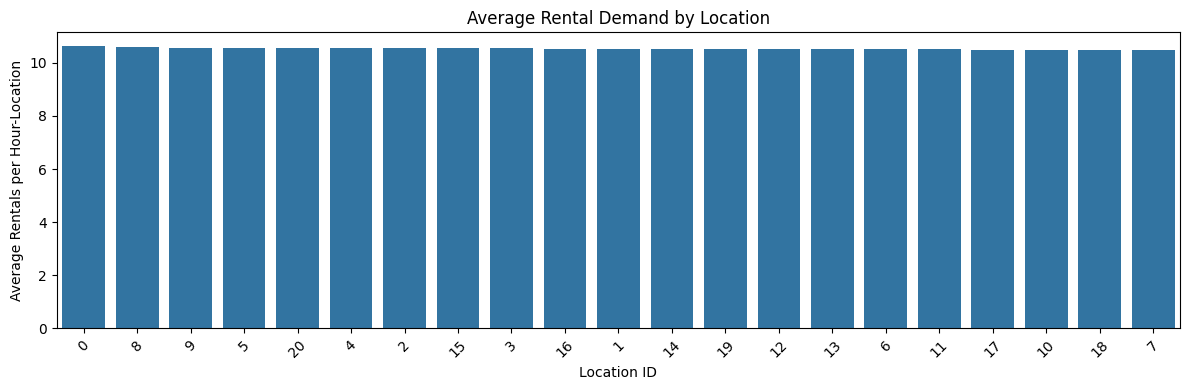


top_locations:


,location_id,average_demand,total_demand,observed_hours
0,0,10.62,157470,14827
8,8,10.59,157403,14860
9,9,10.58,156802,14827
5,5,10.57,157270,14877
20,20,10.55,156848,14862
4,4,10.55,156955,14873
2,2,10.55,157025,14883
15,15,10.55,156852,14868
3,3,10.55,156694,14855
16,16,10.54,156627,14859



bottom_locations:


,location_id,average_demand,total_demand,observed_hours
14,14,10.54,156418,14841
19,19,10.54,156839,14881
12,12,10.54,156815,14880
13,13,10.54,156625,14866
6,6,10.53,156338,14848
11,11,10.52,156677,14889
17,17,10.50,156402,14889
10,10,10.49,156500,14919
18,18,10.48,156362,14913
7,7,10.47,156513,14951


In [34]:
location_demand = (
    analysis_data
    .groupby("location_id", as_index=False)
    .agg(
        average_demand=("total_count", "mean"),
        total_demand=("total_count", "sum"),
        observed_hours=("hour", "nunique")
    )
    .sort_values("average_demand", ascending=False)
)

plt.figure(figsize=(12, 4))

sns.barplot(
    data=location_demand,
    x="location_id",
    y="average_demand",
    order=location_demand["location_id"]
)

plt.title("Average Rental Demand by Location")
plt.xlabel("Location ID")
plt.ylabel("Average Rentals per Hour-Location")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

show_results(
    top_locations=location_demand.head(10).round(2),
    bottom_locations=location_demand.tail(10).round(2)
)

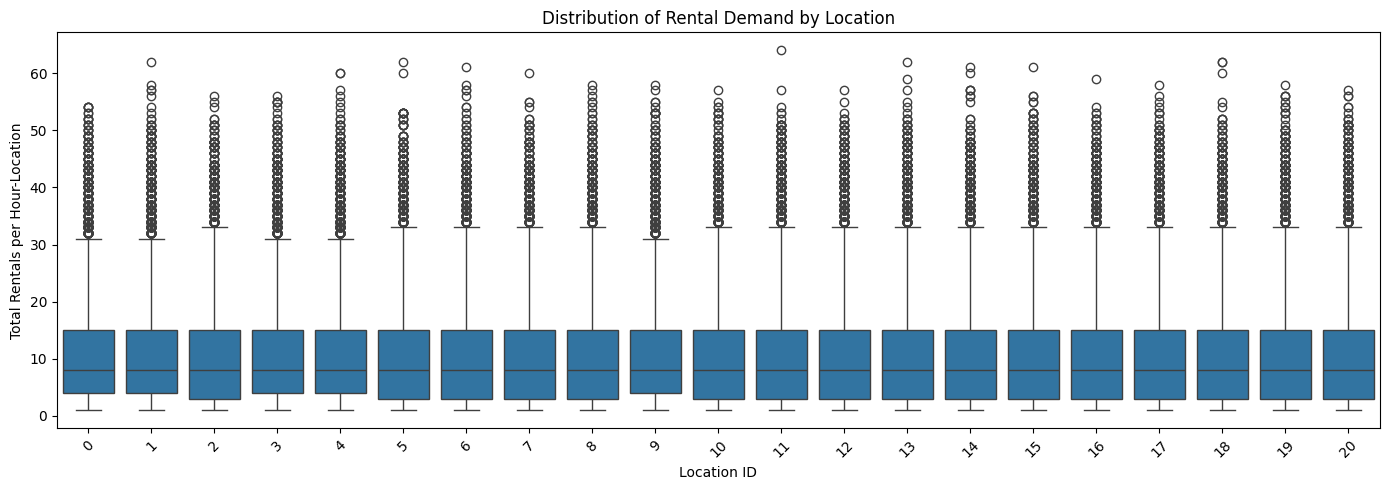

In [36]:
plt.figure(figsize=(14, 5))

sns.boxplot(
    data=analysis_data,
    x="location_id",
    y="total_count"
)

plt.title("Distribution of Rental Demand by Location")
plt.xlabel("Location ID")
plt.ylabel("Total Rentals per Hour-Location")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

It shows very little difference in average rental demand across locations. Most locations have an average demand, and the gap between the highest and lowest demand locations is very small.

The boxplot also shows that the distributions of rental demand are highly similar across locations. This suggests that `location_id` does not provide any interpretable location-specific signal in the current dataset. Thus this feature will be removed from modeling features in the  modeling stage.

## 6. Weather Impact
### 6.1 Prepare Hourly Weather Data

In [37]:
weather_cols = [
    "hour",
    "conditions",
    "temperature_c",
    "perceived_temperature_c",
    "humidity",
    "windspeed_kmh"
]

hourly_weather = (
    analysis_data[weather_cols]
    .drop_duplicates(subset="hour")
)

weather_demand = (
    hourly_data[["hour", "total_count", "registered_count", "direct_count"]]
    .merge(hourly_weather, on="hour", how="left")
)

show_results(
    weather_demand_shape=weather_demand.shape,
    missing_values=weather_demand.isna().sum(),
    first_rows=weather_demand.head()
)


weather_demand_shape:


(17379, 9)


missing_values:


hour                       0
total_count                0
registered_count           0
direct_count               0
conditions                 0
temperature_c              0
perceived_temperature_c    0
humidity                   0
windspeed_kmh              0
dtype: int64


first_rows:


,hour,total_count,registered_count,direct_count,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh
0,2011-01-01 00:00:00,16,13,3,clear,3.3,3.0,81.0,0.0
1,2011-01-01 01:00:00,40,32,8,clear,2.3,2.0,80.0,0.0
2,2011-01-01 02:00:00,32,27,5,clear,2.3,2.0,80.0,0.0
3,2011-01-01 03:00:00,13,10,3,clear,3.3,3.0,75.0,0.0
4,2011-01-01 04:00:00,1,1,0,clear,3.3,3.0,75.0,0.0


### 6.2 Demand by Weather Condition

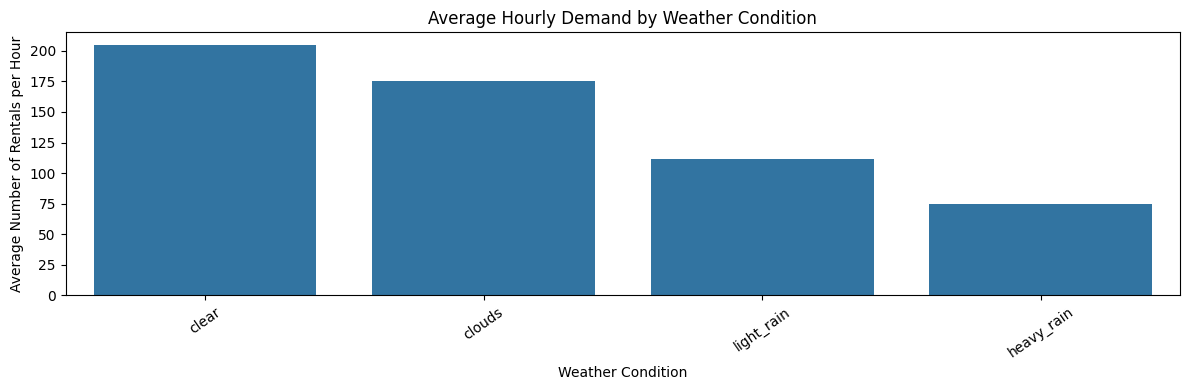


condition_summary:


,conditions,observed_hours,average_demand,median_demand
0,clear,11413,204.87,159.0
1,clouds,4544,175.17,133.0
3,light_rain,1419,111.58,63.0
2,heavy_rain,3,74.33,36.0


In [38]:
condition_summary = (
    weather_demand
    .groupby("conditions", as_index=False)
    .agg(
        observed_hours=("total_count", "count"),
        average_demand=("total_count", "mean"),
        median_demand=("total_count", "median")
    )
    .sort_values("average_demand", ascending=False)
)

plt.figure(figsize=(12, 4))

sns.barplot(
    data=condition_summary,
    x="conditions",
    y="average_demand",
    order=condition_summary["conditions"]
)

plt.title("Average Hourly Demand by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Number of Rentals per Hour")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

show_results(
    condition_summary=condition_summary.round(2)
)

### 6.3 Demand by Numeric Weather Variables

In [39]:
weather_numeric_cols = [
    "temperature_c",
    "perceived_temperature_c",
    "humidity",
    "windspeed_kmh"
]

weather_correlations = (
    weather_demand[weather_numeric_cols + ["total_count"]]
    .corr(numeric_only=True)["total_count"]
    .drop("total_count")
    .sort_values(ascending=False)
)

show_results(
    weather_correlations=weather_correlations.round(3)
)


weather_correlations:


temperature_c              0.405
perceived_temperature_c    0.401
windspeed_kmh              0.093
humidity                  -0.323
Name: total_count, dtype: float64

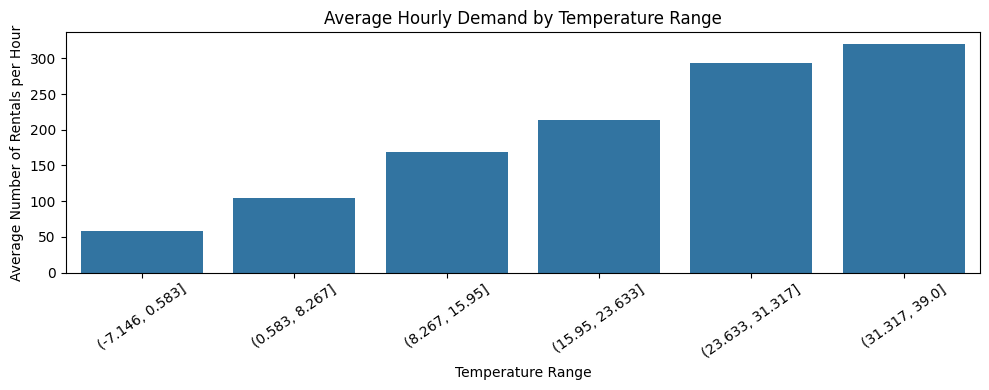


temperature_bin_summary:


,temperature_bin,observed_hours,average_demand
0,"(-7.146, 0.583]",716,57.81
1,"(0.583, 8.267]",4054,104.69
2,"(8.267, 15.95]",4090,168.96
3,"(15.95, 23.633]",4795,214.30
4,"(23.633, 31.317]",3228,294.08
5,"(31.317, 39.0]",496,320.52


In [41]:
weather_demand["temperature_bin"] = pd.cut(
    weather_demand["temperature_c"],
    bins=6
)

temperature_bin_summary = (
    weather_demand
    .groupby("temperature_bin", observed=True, as_index=False)
    .agg(
        observed_hours=("total_count", "count"),
        average_demand=("total_count", "mean")
    )
)

plt.figure(figsize=(10, 4))

sns.barplot(
    data=temperature_bin_summary,
    x="temperature_bin",
    y="average_demand"
)

plt.title("Average Hourly Demand by Temperature Range")
plt.xlabel("Temperature Range")
plt.ylabel("Average Number of Rentals per Hour")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

show_results(
    temperature_bin_summary=temperature_bin_summary.round(2)
)

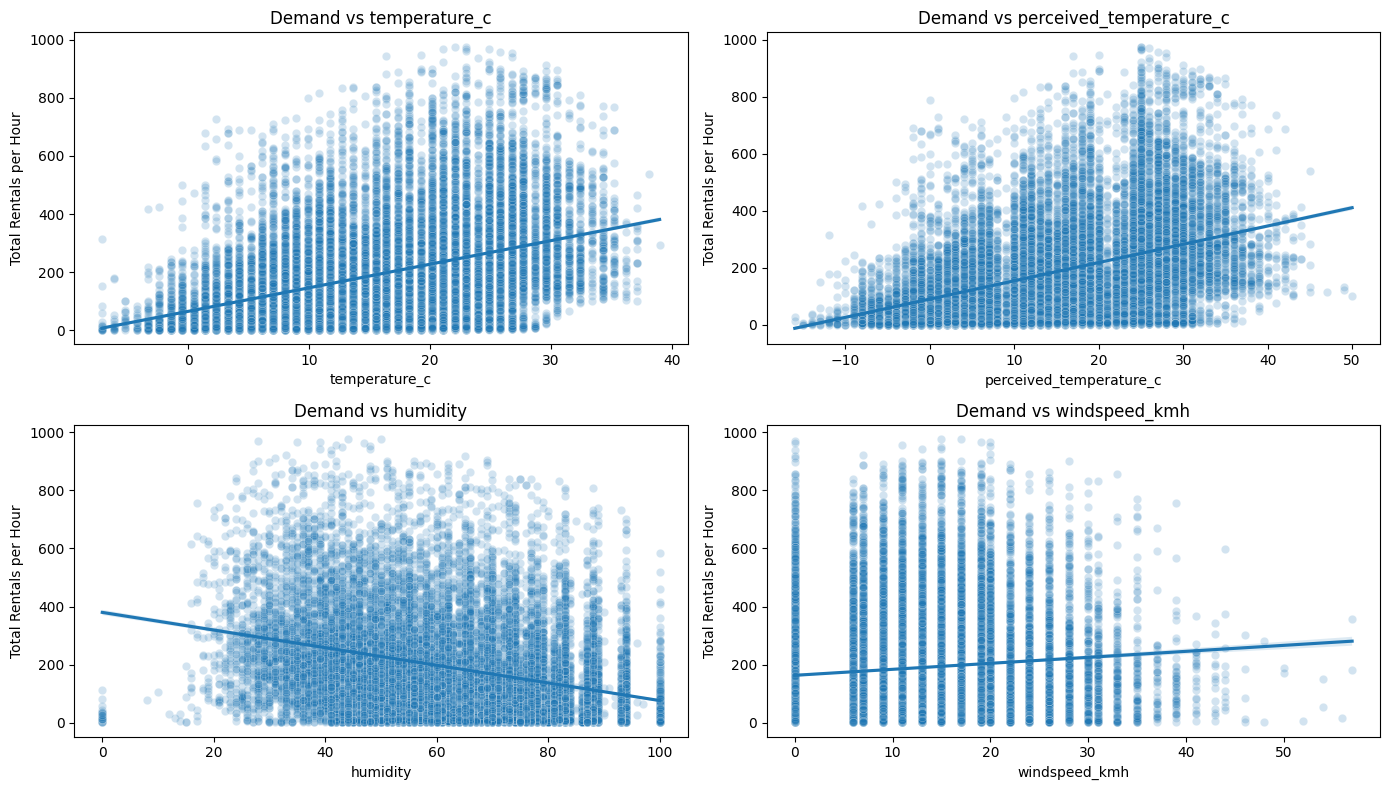

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes = axes.flatten()

for ax, col in zip(axes, weather_numeric_cols):
    sns.scatterplot(
        data=weather_demand,
        x=col,
        y="total_count",
        alpha=0.2,
        ax=ax
    )
    
    sns.regplot(
        data=weather_demand,
        x=col,
        y="total_count",
        scatter=False,
        ax=ax
    )
    
    ax.set_title(f"Demand vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Total Rentals per Hour")

plt.tight_layout()
plt.show()

Weather variables show a clear relationship with bike rental demand. They should be retained for modeling, especially `temperature_c`, `perceived_temperature_c`, `humidity`, and `conditions`.

Demand increases as temperature and perceived temperature rise, while humidity shows a negative relationship with demand. Wind speed does not show a strong negative effect in this dataset. The temperature range analysis confirms this pattern more clearly. This suggests that temperature is an important weather-related feature for later modeling.

Weather condition also shows a clear demand difference. Clear weather has the highest average hourly demand, followed by cloudy weather, while light rain is associated with much lower demand. Heavy rain has the lowest average demand, but it only appears in **3 observed hours**, so this category should be interpreted cautiously.

## 7. EDA Conclusion and Modeling Features

The EDA shows that bike rental demand is mainly influenced by time patterns, day type, weather conditions and season.

Based on these findings, the first modeling stage will focus on system-level hourly demand prediction. Useful candidate features include:

- `hour_of_day`
- `day_of_week`
- `month` or `quarter`
- `is_workday`
- `is_weekend`
- `is_holiday`
- `conditions`
- `temperature_c`
- `perceived_temperature_c`
- `humidity`
- `windspeed_kmh`

For feature engineering, cyclical encoding may be applied to time variables such as `hour_of_day`, `day_of_week`, and `month`.

The `conditions` feature should be encoded as a categorical variable with one-hot encoding. Since `temperature_c` and `perceived_temperature_c` may be highly correlated, their usefulness should be compared during modeling.